# Gulfstream walkthrough — equities (`equity_eod`)

Same Graph 1 core path as the YCS notebook, but starting from **equity end-of-day bars**.

1. Inspect `equity_eod` in DuckDB
2. Pivot a basket of closes to a wide dated frame
3. Convert to log prices (pipeline-friendly levels)
4. Run Hamilton segmentation
5. Plot detected regimes

**Database:** `D:/data/duckdb/equity_eod_data.duckdb` · **table:** `equity_eod`

> **Windows tip:** if DuckDB says the file is locked, close DBeaver (or any other client) and re-run.
> This notebook falls back to `equity_eod_data_copy.duckdb` when present.


## 0. Project setup


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import duckdb
import pandas as pd
import polars as pl
from plotnine import aes, geom_line, ggplot, labs, theme_bw, facet_wrap, theme

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "pyproject.toml").exists():
    ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "pyproject.toml").exists():
    ROOT = NOTEBOOK_DIR.parent
else:
    ROOT = Path(r"D:/Code/gulfstream")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

EQ_CANDIDATES = [
    Path(r"D:/data/duckdb/equity_eod_data.duckdb"),
    Path(r"D:/data/duckdb/equity_eod_data_copy.duckdb"),
]
EQ_DB = next((p for p in EQ_CANDIDATES if p.exists()), EQ_CANDIDATES[0])
OUT_DIR = ROOT / "outputs" / "notebooks" / "equity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("EQ_DB =", EQ_DB, "exists =", EQ_DB.exists())


ROOT = d:\Code\gulfstream
EQ_DB = D:\data\duckdb\equity_eod_data.duckdb exists = True


## 1. Schema & coverage

Columns: `Index` (date), `Stock`, OHLC, `Volume`, `EqIndex` (e.g. `DAX30`, `CAC40`, `SP500`).


In [2]:
def open_equity() -> duckdb.DuckDBPyConnection:
    try:
        return duckdb.connect(str(EQ_DB), read_only=True)
    except Exception as exc:
        raise RuntimeError(
            f"Could not open {EQ_DB}. Close DBeaver / other DuckDB clients and retry.\n{exc}"
        ) from exc

con = open_equity()
print(con.execute("DESCRIBE equity_eod").pl())
print(
    con.execute(
        """
        SELECT EqIndex, COUNT(*) AS n, COUNT(DISTINCT Stock) AS stocks,
               MIN(Index) AS dmin, MAX(Index) AS dmax
        FROM equity_eod
        GROUP BY 1
        ORDER BY n DESC
        """
    ).pl()
)
con.close()


shape: (9, 6)
┌─────────────┬─────────────┬──────┬──────┬─────────┬───────┐
│ column_name ┆ column_type ┆ null ┆ key  ┆ default ┆ extra │
│ ---         ┆ ---         ┆ ---  ┆ ---  ┆ ---     ┆ ---   │
│ str         ┆ str         ┆ str  ┆ str  ┆ str     ┆ str   │
╞═════════════╪═════════════╪══════╪══════╪═════════╪═══════╡
│ Index       ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
│ Stock       ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
│ Open        ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ High        ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ Low         ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ Close       ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ Volume      ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ EqIndex     ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
│ file_source ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
└─────────────┴─────────────┴──────┴──────┴─────────┴───────┘
shape: (6, 5)
┌─────────┬─────────┬────────┬────────────

## 2. Build a wide close panel

We use **DAX30** over the GFC window so structural breaks are visible, keep the first
`N_TICKERS` names for a manageable feature set, and drop incomplete dates.


In [3]:
EQ_INDEX = "DAX30"
START, END = "2007-01-01", "2012-12-31"
N_TICKERS = 8

con = open_equity()
long = con.execute(
    f"""
    SELECT CAST(Index AS DATE) AS date,
           Stock AS ticker,
           Close AS close
    FROM equity_eod
    WHERE EqIndex = '{EQ_INDEX}'
      AND Index >= '{START}'
      AND Index <= '{END}'
    ORDER BY date, ticker
    """
).pl()
con.close()

print(long.head())
print("rows:", long.height, "tickers:", long["ticker"].n_unique())

from gulfstream.common import frames

wide = (
    long.pivot(values="close", index="date", on="ticker", aggregate_function="first")
    .sort("date")
)
wide = frames.ensure_date_column(wide)
tickers = frames.feature_columns(wide)[:N_TICKERS]
wide = wide.select(["date", *tickers]).drop_nulls()
print("wide shape:", wide.shape)
print("tickers:", tickers)
wide.head(3)


shape: (5, 3)
┌────────────┬─────────┬───────────┐
│ date       ┆ ticker  ┆ close     │
│ ---        ┆ ---     ┆ ---       │
│ date       ┆ str     ┆ f32       │
╞════════════╪═════════╪═══════════╡
│ 2007-01-02 ┆ ADS.DE  ┆ 37.91     │
│ 2007-01-02 ┆ ALV.DE  ┆ 156.5     │
│ 2007-01-02 ┆ BAS.DE  ┆ 37.41     │
│ 2007-01-02 ┆ BAYN.DE ┆ 40.593899 │
│ 2007-01-02 ┆ BEI.DE  ┆ 50.150002 │
└────────────┴─────────┴───────────┘
rows: 45750 tickers: 30
wide shape: (1525, 9)
tickers: ['ADS.DE', 'ALV.DE', 'BAS.DE', 'BAYN.DE', 'BEI.DE', 'BMW.DE', 'CON.DE', 'DAI.DE']


date,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CON.DE,DAI.DE
datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32
2007-01-02 00:00:00,37.91,156.5,37.41,40.593899,50.150002,43.799999,85.813797,47.599998
2007-01-03 00:00:00,38.029999,157.520004,37.235001,40.780899,50.259998,44.049999,85.697701,47.5
2007-01-04 00:00:00,37.799999,159.449997,36.830002,40.613602,50.59,43.639999,85.059502,47.150002


## 3. Visualize raw closes


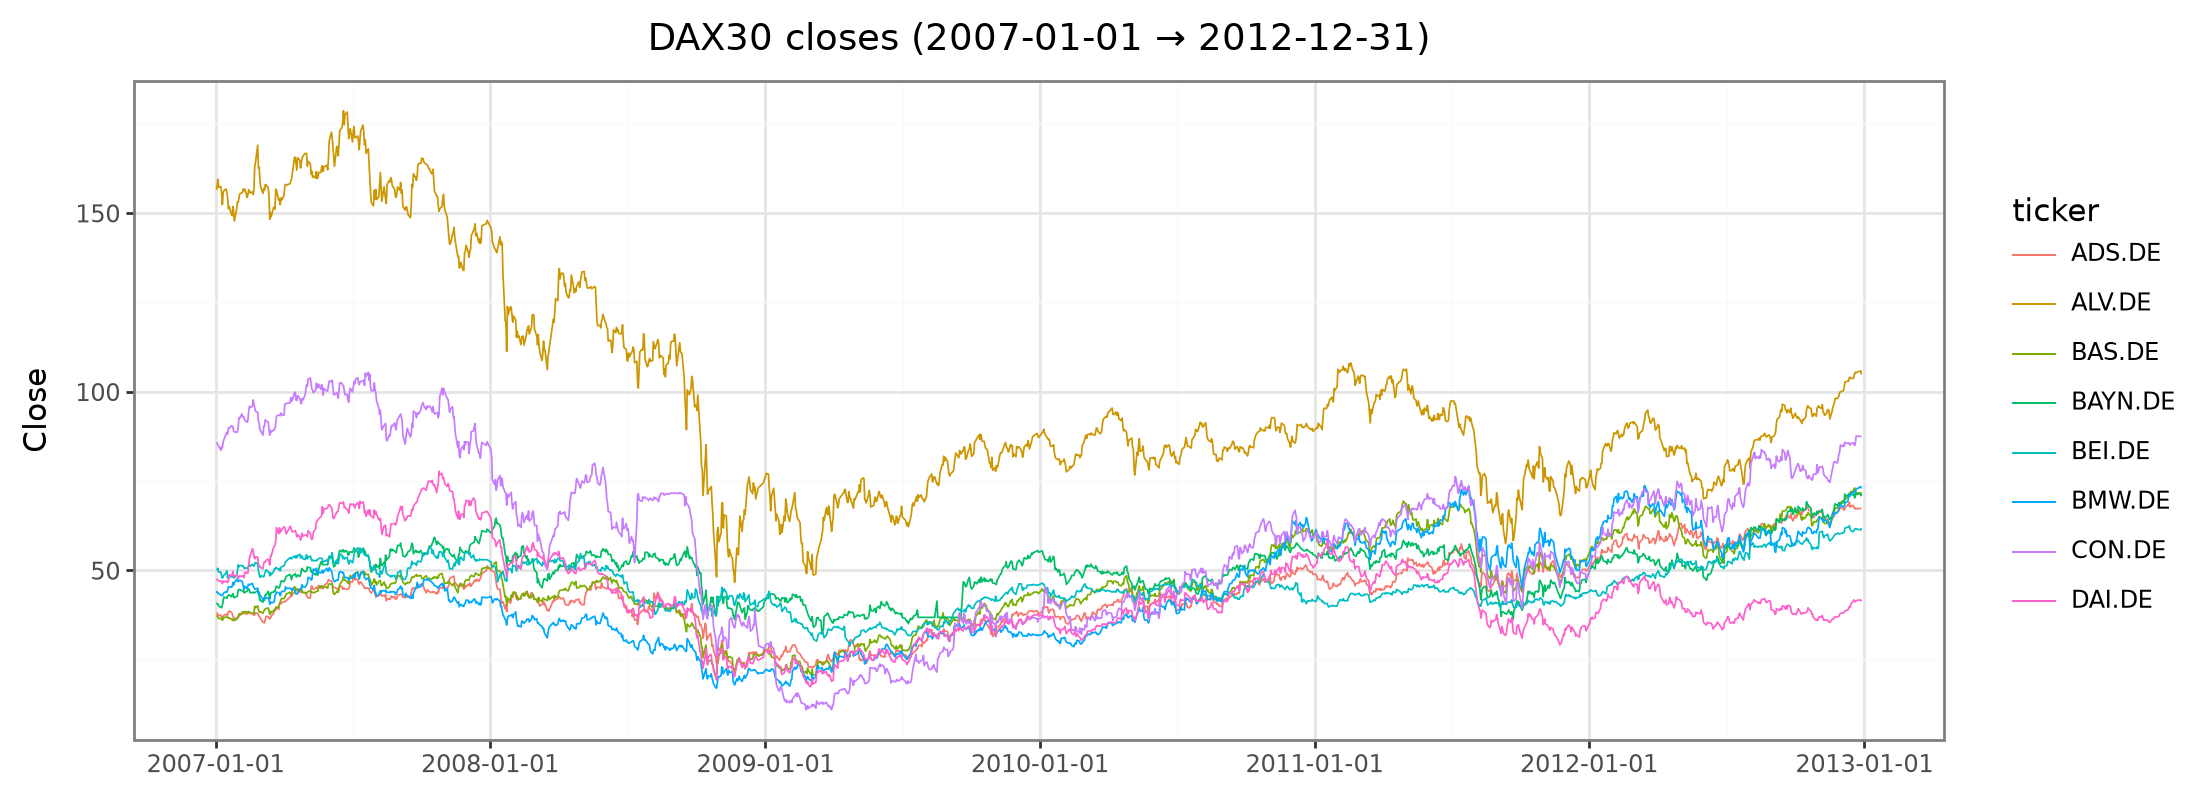

In [4]:
long_px = (
    wide.unpivot(index="date", on=tickers, variable_name="ticker", value_name="close")
    .to_pandas()
)
long_px["date"] = pd.to_datetime(long_px["date"])

(
    ggplot(long_px, aes("date", "close", color="ticker"))
    + geom_line(size=0.35)
    + theme_bw()
    + theme(figure_size=(11, 4))
    + labs(title=f"{EQ_INDEX} closes ({START} → {END})", x="", y="Close")
)


## 4. Feature engineering for the detector

Yield-curve helpers expect `SOURCE_Yxxxp0` names. For equities we stay in **log-price space**
(smooth levels that still carry regime structure) — the same shape the PCA / RFF / ruptures
stack expects: a dated wide polars frame of numeric features.


In [5]:
features_df = wide.with_columns([pl.col(c).log().alias(c) for c in tickers])
vol_window = 20
for c in tickers:
    r = f"{c}_ret"
    v = f"{c}_vol"
    features_df = features_df.with_columns((pl.col(c).diff()).alias(r))
    features_df = features_df.with_columns(pl.col(r).rolling_std(vol_window).alias(v))

features_df = features_df.drop_nulls()
print("features:", features_df.shape, "n_feat:", frames.n_features(features_df))
print(frames.feature_columns(features_df)[:12])
features_df.head(3)


features: (1505, 25) n_feat: 24
['ADS.DE', 'ALV.DE', 'BAS.DE', 'BAYN.DE', 'BEI.DE', 'BMW.DE', 'CON.DE', 'DAI.DE', 'ADS.DE_ret', 'ADS.DE_vol', 'ALV.DE_ret', 'ALV.DE_vol']


date,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CON.DE,DAI.DE,ADS.DE_ret,ADS.DE_vol,ALV.DE_ret,ALV.DE_vol,BAS.DE_ret,BAS.DE_vol,BAYN.DE_ret,BAYN.DE_vol,BEI.DE_ret,BEI.DE_vol,BMW.DE_ret,BMW.DE_vol,CON.DE_ret,CON.DE_vol,DAI.DE_ret,DAI.DE_vol
datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2007-01-30 00:00:00,3.606041,5.031157,3.59786,3.757188,3.90962,3.851849,4.485427,3.880945,0.006813,0.010059,0.012752,0.013608,0.003566,0.008776,0.0023,0.013305,0.026202,0.016062,-0.009302,0.011333,-0.000436,0.010026,-0.00576,0.013292
2007-01-31 00:00:00,3.608754,5.030438,3.609972,3.795065,3.942552,3.845883,4.497562,3.864093,0.002712,0.010048,-0.000719,0.013492,0.012111,0.009218,0.037877,0.015464,0.032932,0.017697,-0.005965,0.011519,0.012135,0.010264,-0.016853,0.013864
2007-02-01 00:00:00,3.614964,5.038121,3.633367,3.799479,3.93163,3.85397,4.530088,3.876189,0.00621,0.010128,0.007683,0.013288,0.023395,0.01028,0.004415,0.015335,-0.010922,0.017853,0.008087,0.011188,0.032526,0.012001,0.012096,0.013989


## 5. Feature snapshot (log prices + vols)


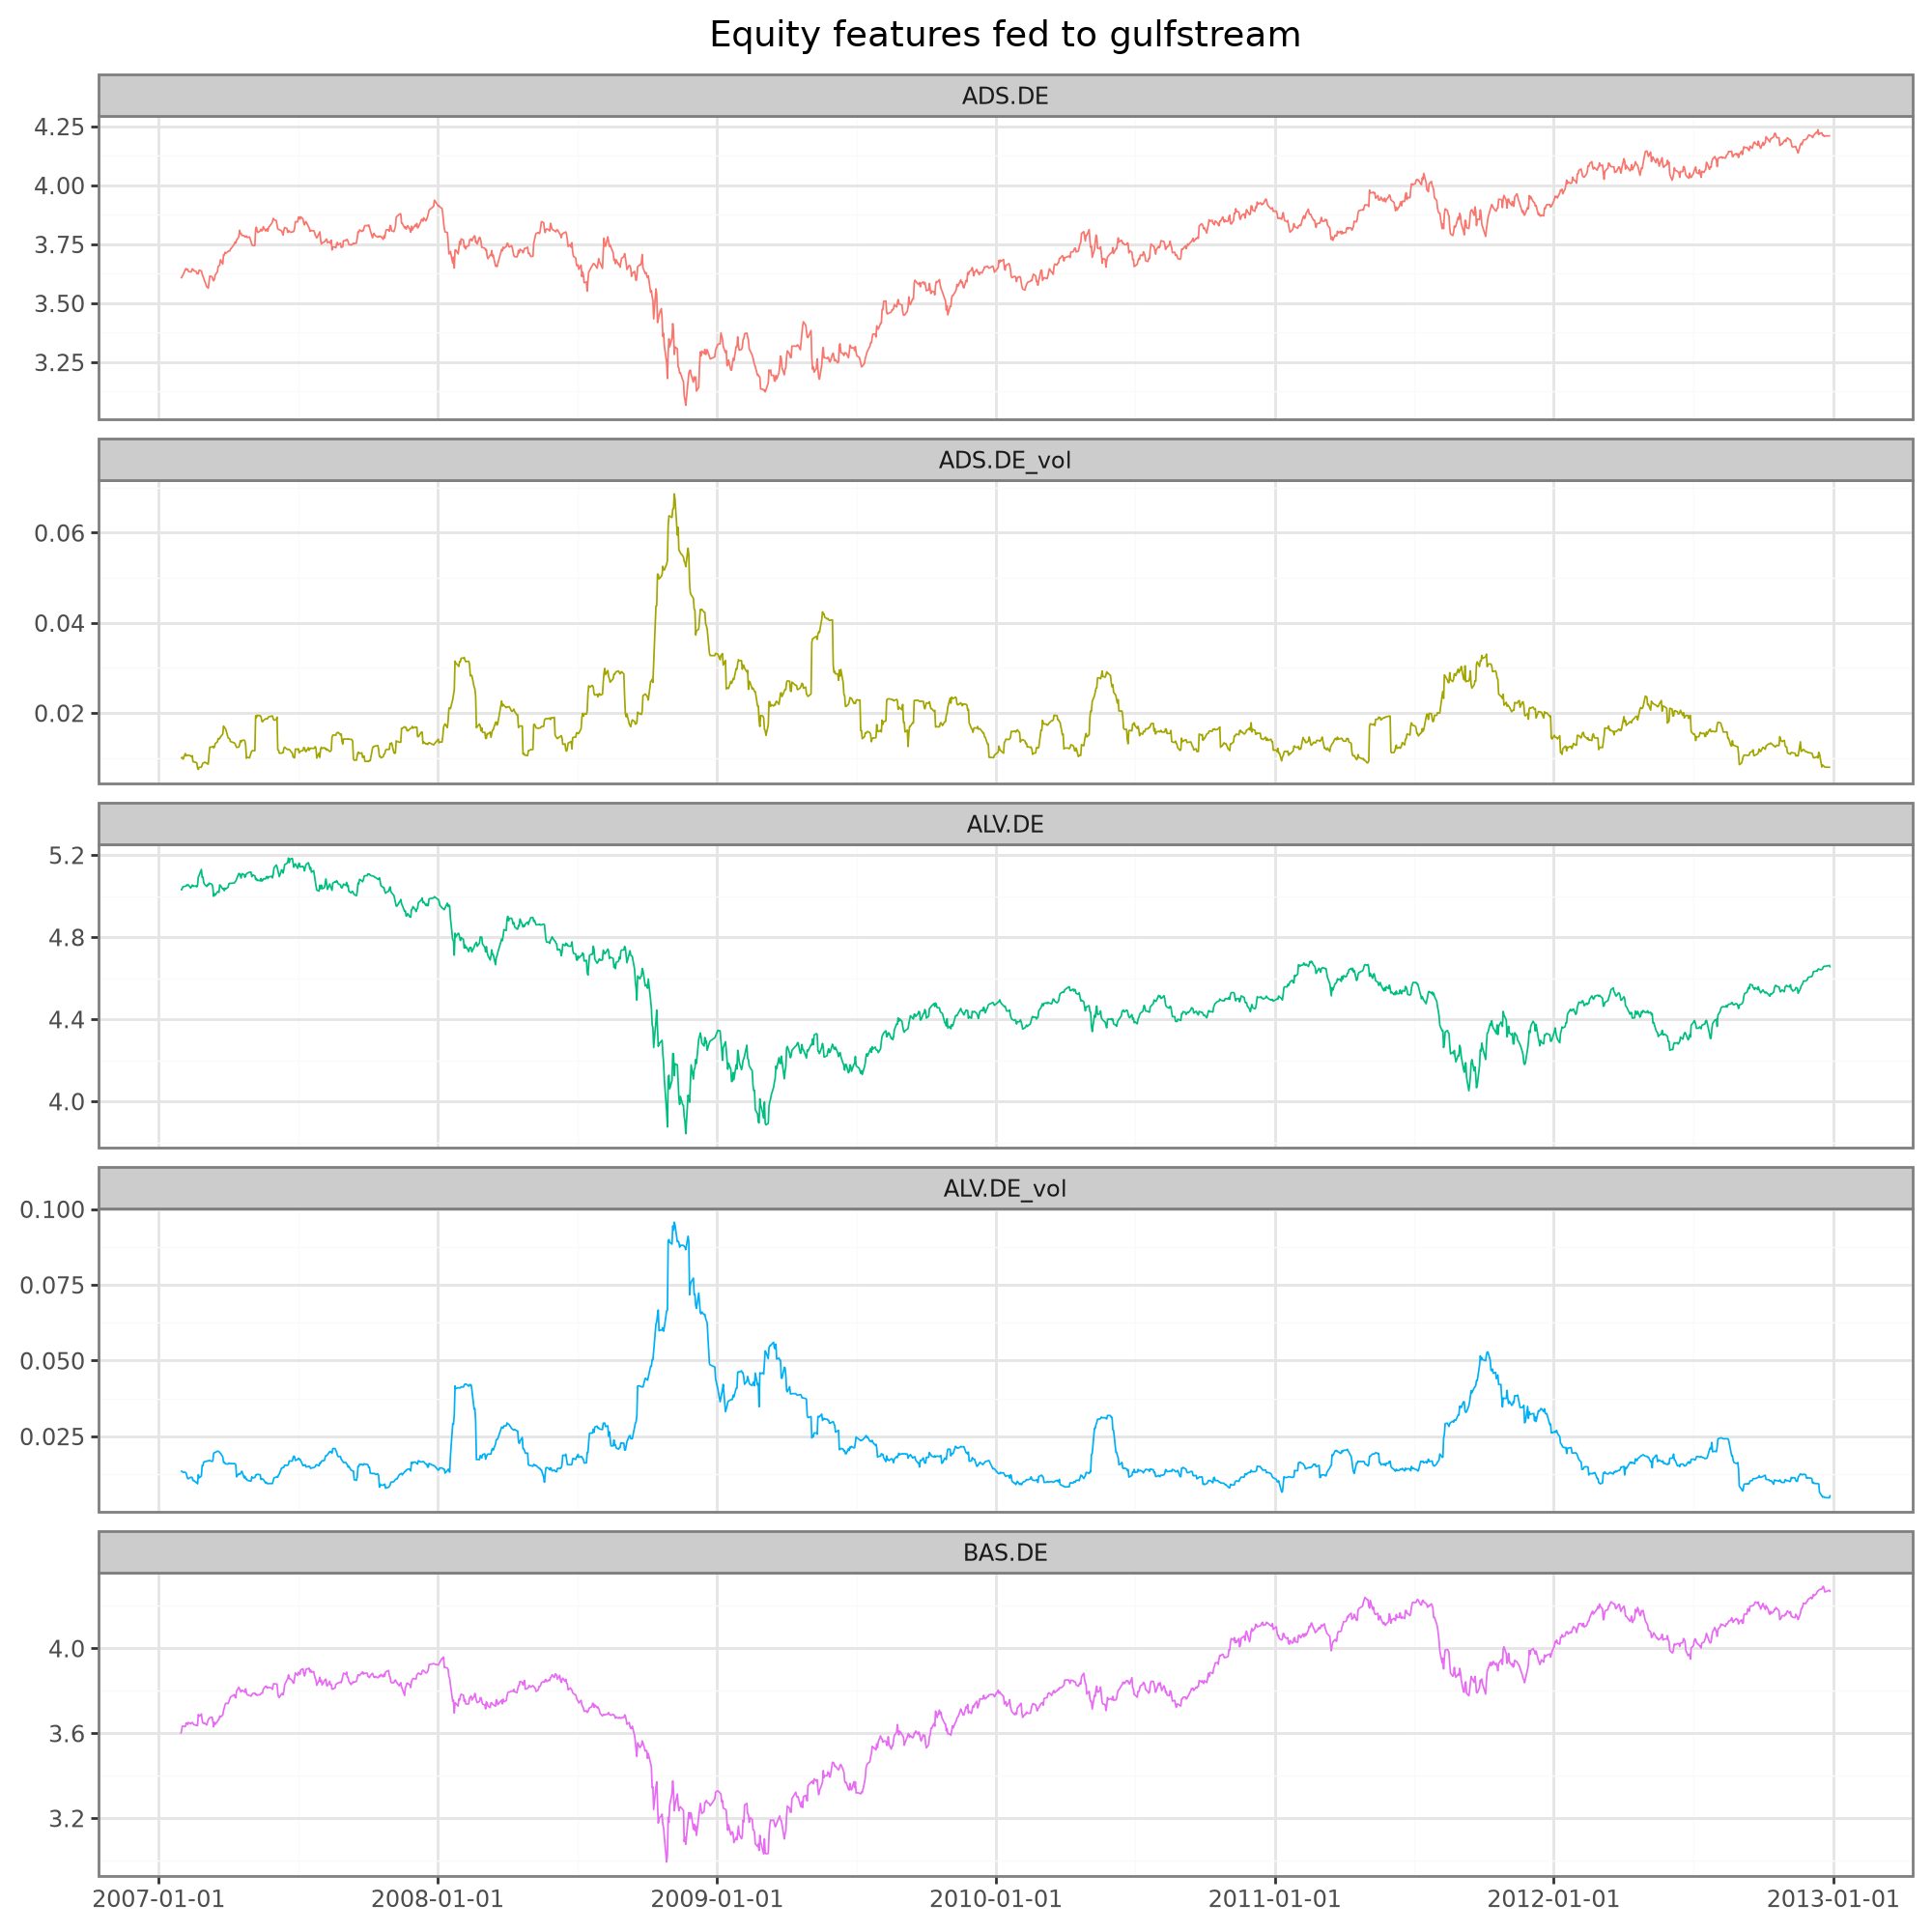

In [6]:
viz_cols = tickers[:3] + [f"{tickers[0]}_vol", f"{tickers[1]}_vol"]
viz_cols = [c for c in viz_cols if c in features_df.columns]
long_f = (
    features_df.select(["date", *viz_cols])
    .unpivot(index="date", on=viz_cols, variable_name="series", value_name="value")
    .to_pandas()
)
long_f["date"] = pd.to_datetime(long_f["date"])

(
    ggplot(long_f, aes("date", "value", color="series"))
    + geom_line(size=0.35)
    + facet_wrap("~series", scales="free_y", ncol=1)
    + theme_bw()
    + theme(figure_size=(10, 2.0 * len(viz_cols)), legend_position="none")
    + labs(title="Equity features fed to gulfstream", x="", y="")
)


## 6. Core config

Slightly looser significance than the default YCS smoke settings so equity breaks survive the
MMD gate in this educational window. Robustness / stability stay off for speed.


In [8]:
from gulfstream.common import utils
from gulfstream.pipelines.hamilton.driver import run_segmentation_pair
from gulfstream.detection import time_index as bkpt_time
from gulfstream.metrics import regime_plots
from gulfstream.metrics.regime_plots import _visualize_market_regimes

params = utils.read_config_yaml(
    str(ROOT / "config" / "graph1" / "default_core.yaml"),
    img_dir=str(OUT_DIR),
    log_dir=str(ROOT / "outputs" / "logs"),
)
params["test_num"] = 0
params["metrics"]["mode"] = "display_and_write"
params["metrics"]["plot"] = True
params["metrics"]["dir"] = str(OUT_DIR)
params["metrics"]["image_dir"] = str(OUT_DIR)
params["metrics"]["features_to_plot"] = tickers[:3]
params["robustness"]["enabled"] = False
params["stability"]["enabled"] = False
params["algo"]["min_regime_length"] = [20]
params["algo"]["depth"] = [2]
params["test"]["significance_level"] = [0.2]
params["test"]["window"] = [{"method": "user_specified", "window": 60}]
params["test"]["sample_size"] = [{"method": "user_specified", "num_samples": 60}]

print(params["algo"]["dimred"], params["test"]["choice"])


['pca'] ['mmd_no_ts']


## 7. Run segmentation


In [9]:
unprocessed, processed = run_segmentation_pair(features_df, params)

print("raw breakpoints:", unprocessed.bkpts)
print("kept breakpoints:", processed.bkpts)
print("invalid:", processed.invalid_bkpts)

dates = frames.dates_series(features_df).to_list()
for b in processed.bkpts:
    print(f"  bkpt {b} → {dates[b]}")

hierarchy = processed.hierarchy or {b: 1 for b in processed.bkpts}
regimes_df = bkpt_time._get_regime_intervals(hierarchy, dates)
regimes_df


raw breakpoints: [40, 70]
kept breakpoints: [40, 70]
invalid: []
  bkpt 40 → 2007-03-27 00:00:00
  bkpt 70 → 2007-05-11 00:00:00


Start,End,Regime
datetime[μs],datetime[μs],i64
2007-01-30 00:00:00,2007-03-26 00:00:00,0
2007-03-27 00:00:00,2007-05-10 00:00:00,1
2007-05-11 00:00:00,2012-12-28 00:00:00,2


## 8. Regime plots


In [10]:
regime_plots.produce_all_regime_visualization_tools(features_df, params, processed)

_visualize_market_regimes(
    features_df,
    regimes_df,
    title=f"{EQ_INDEX} regimes (log prices)",
    variables=tickers[:2],
    valid_bkpts=processed.bkpts,
    invalid_bkpts=processed.invalid_bkpts,
    low_confidence_bkpts=list(processed.low_confidence_bkpts or []),
    mode="display",
)
print("Saved under", OUT_DIR)


<ggplot: (1400 x 839)>
<ggplot: (1400 x 560)>
Saved under d:\Code\gulfstream\outputs\notebooks\equity


## 9. What to try next

- Change `EQ_INDEX` to `CAC40` / `SP500` (keep `N_TICKERS` small for SP500).
- Swap log prices for pure returns and compare accepted breakpoints.
- Run the same frame through a **legacy** detector via `config/legacy/legacy_kmeans.yaml`.
- Mirror the YCS path with a custom source YAML whose `sql:` returns a wide dated frame.
